## Wizualizacja embeddingu obrazów i tekstów

In [1]:
import os
import sys

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [9]:
import random
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from datasets.coco_dataset import COCO_Dataset
from models.inferencer import ModelInferencer


In [10]:
DATA_DIR = Path("../data/coco") 
CHECKPOINT_PATH = Path("../checkpoint/abl_distilroberta_20260320_121707_checkpoint.pth.tar") 

In [11]:
dataset = COCO_Dataset(
    image_dir=DATA_DIR / "val2017",
    annotation_file=DATA_DIR / "annotations" / "captions_val2017.json",
    img_transform=None 
)

# Losowanie próbki

Wybieramy losową próbkę danych ze zbioru walidacyjnego i zapisujemy obrazy oraz odpowiadające im podpisy w tablicach (dla każdego obrazu wybieramy jeden podpis)

In [12]:
N = 100
indices = random.sample(range(len(dataset)), N)

image_paths = []
texts = []

for idx in indices:
    img_path, captions = dataset.samples[idx]
    image_paths.append(img_path)
    texts.append(captions[0]) 

# Wczytanie modelu

Wczytujemy wytrenowany model z zapisanego pliku z wagami

In [13]:
inferencer = ModelInferencer(CHECKPOINT_PATH)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13758.62it/s]


Załadowano: abl_distilroberta | epoch 10 | val_loss 1.3112


# Embedding

Dla danych tekstowych oraz obrazów tworzymy embeddingi z użyciem wytrenowanego modelu

In [14]:
image_embeds = inferencer.embed_image(image_paths)
text_embeds = inferencer.embed_text(texts)

image_embeds = image_embeds.numpy()
text_embeds = text_embeds.numpy()

# Złączenie wektorów

Łączymy wektory zawierające kodowanie obrazów i tekstu

In [15]:
combined = np.vstack([image_embeds, text_embeds])

# PCS + t-SNE oraz UMAP

In [16]:
pca = PCA(n_components=50)
combined_pca_50 = pca.fit_transform(combined)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
combined_tsne = tsne.fit_transform(combined_pca_50)

umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
combined_umap = np.asarray(umap_model.fit_transform(combined))

# Podział wektorów

Dzielimy z powrotem na wektory zawierające kodowanie obrazów i tekstu

In [17]:
def split_embeddings(combined_2d: np.ndarray, n: int) -> Tuple[np.ndarray, np.ndarray]:
    return combined_2d[:n], combined_2d[n:]

img_tsne, txt_tsne = split_embeddings(combined_tsne, N)
img_umap, txt_umap = split_embeddings(combined_umap, N)

#  Rysowanie wykresów

Definiujemy funkcję do rysowania wykresów i tworzymy wykresy dla danych przetworzonych za pomocą PCA i t-SNE oraz UMAP

In [18]:
def plot_embeddings(
    img_2d: np.ndarray,
    txt_2d: np.ndarray,
    title: str,
    draw_lines: bool = True,
    max_lines: int = 200  
) -> None:
    plt.figure(figsize=(8, 6))

    plt.scatter(img_2d[:, 0], img_2d[:, 1], alpha=1.0, label="Images")
    plt.scatter(txt_2d[:, 0], txt_2d[:, 1], alpha=1.0, label="Text")

    if draw_lines:
        n = min(len(img_2d), max_lines)
        for i in range(n):
            plt.plot(
                [img_2d[i, 0], txt_2d[i, 0]],
                [img_2d[i, 1], txt_2d[i, 1]],
                alpha=0.5
            )

    plt.legend()
    plt.title(title)
    plt.show()

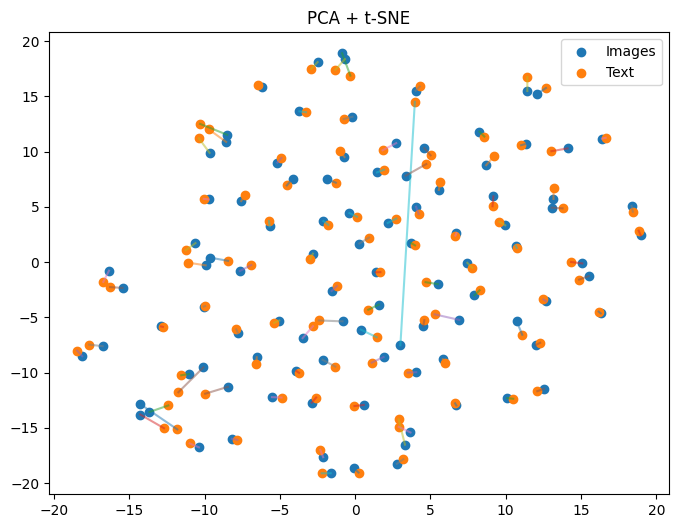

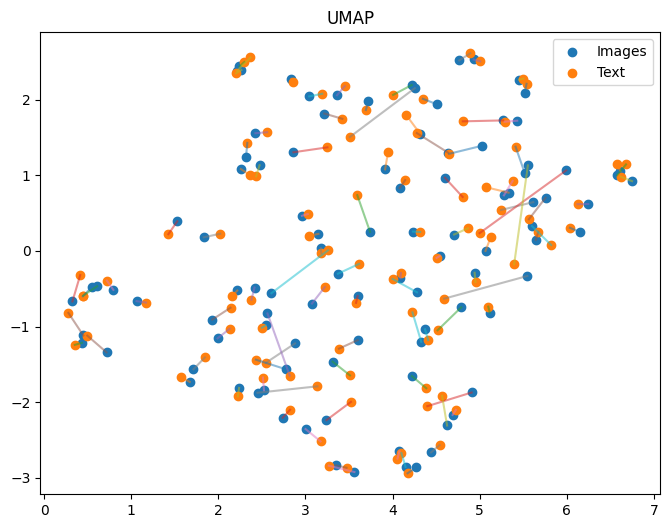

In [19]:
plot_embeddings(img_tsne, txt_tsne, "PCA + t-SNE")
plot_embeddings(img_umap, txt_umap, "UMAP")